# Перевірка власноруч реалізованих алгоритмів кластеризації шляхом порівняння результатів із бібліотечними рішеннями

## Ініціалізація

In [26]:
import matplotlib.pyplot as plt
import numpy as np

random_state = 27

In [27]:
dataset = np.array([
    (1, 5),
    (2, 4),
    (2, 7),
    (2, 9),
    (3, 1),
    (5, 5),
    (5, 7),
    (6, 6),
    (7, 6),
    (10, 6),
])

## K-Means

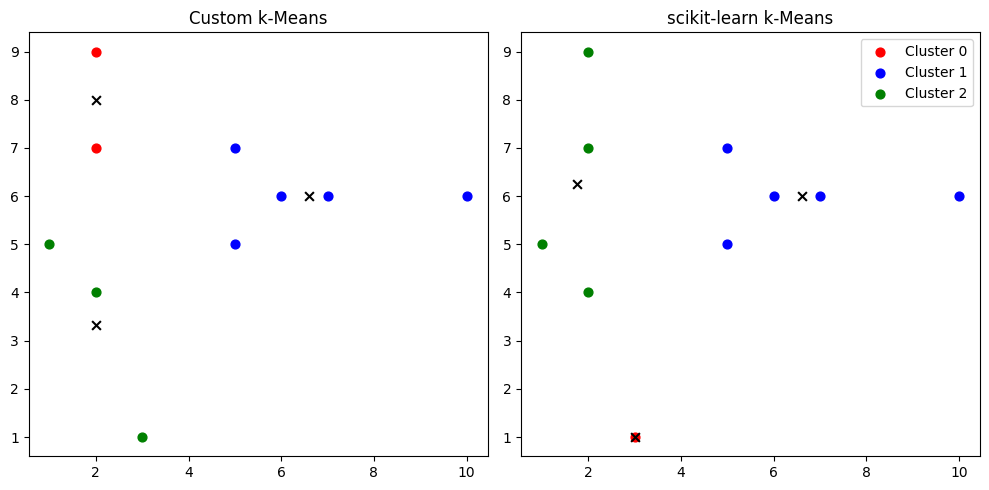

In [28]:
from clasterization import k_means
from sklearn.cluster import KMeans

k_means_cluster_n = 3
kmeans_sk = KMeans(n_clusters=k_means_cluster_n, random_state=random_state)

kmeans_sk_res = kmeans_sk.fit(dataset)
kmeans_sk_labels = kmeans_sk_res.labels_
kmeans_sk_centers = kmeans_sk_res.cluster_centers_


kmeans_custom_labels, kmeans_custom_clusters = k_means(dataset, k_means_cluster_n, random_state=random_state)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

def plot_clusters(ax, X, labels, centers, title):
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i in range(len(centers)):
        cluster_points = X[labels == i]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   label=f'Cluster {i}', color=colors[i % len(colors)], s=40)
        ax.scatter(*centers[i], color='black', marker='x', s=40)
    ax.set_title(title)

plot_clusters(axes[0], dataset, kmeans_custom_labels, kmeans_custom_clusters, "Custom k-Means")
plot_clusters(axes[1], dataset, kmeans_sk_labels, kmeans_sk_centers, "scikit-learn k-Means")

plt.legend()
plt.tight_layout()
plt.show()

Результати власноручної імплементації дещо відрізняються від бібліотечного рішення переважно через ініціалізацію сентроїдів. Власноручна імплементація використовує рандом, тоді як бібліотечна використовує  k-means++, яка ініціалізує центроїди так щоб вони були більш розкидані по простору, що покращує стабільність

## K-Meadians

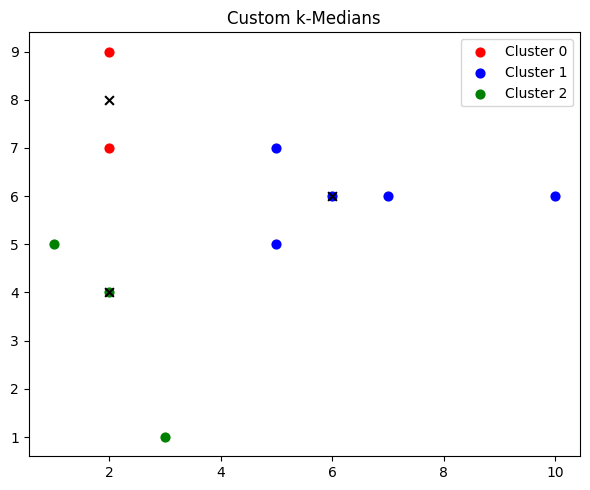

In [29]:
k_medians_cluster_n = 3
from clasterization import k_medians
kmedians_custom_labels, kmedians_custom_clusters = k_medians(dataset, k_means_cluster_n, random_state=random_state)

fig, ax = plt.subplots(figsize=(6, 5))

def plot_clusters(ax, X, labels, centers, title):
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i in range(len(centers)):
        cluster_points = X[labels == i]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   label=f'Cluster {i}', color=colors[i % len(colors)], s=40)
        ax.scatter(*centers[i], color='black', marker='x', s=40)
    ax.set_title(title)

plot_clusters(ax, dataset, kmedians_custom_labels, kmedians_custom_clusters, "Custom k-Medians")

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
def mark_labels_with_clusters(neighbors, labels):
    cluster_id = 0
    for i in range(len(dataset)):
        if labels[i] == -1:
        # Assign a new cluster id to this point and all its neighbors
            stack = [i]
            while stack:
                idx = stack.pop()
                if labels[idx] == -1:
                    labels[idx] = cluster_id
                # Add all unassigned neighbors to the stack
                    for n in neighbors[idx]:
                        if labels[n] == -1:
                            stack.append(n)
            cluster_id += 1
    return cluster_id

## Nearest Neighbors

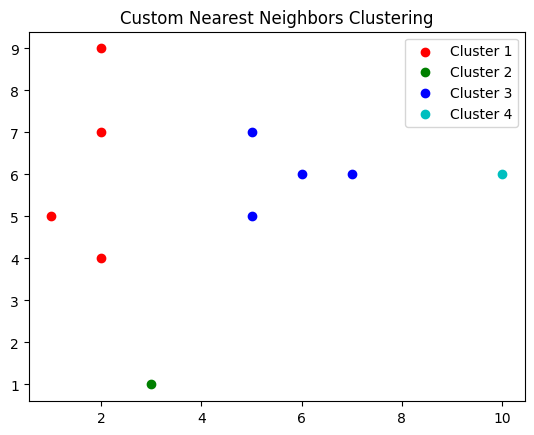

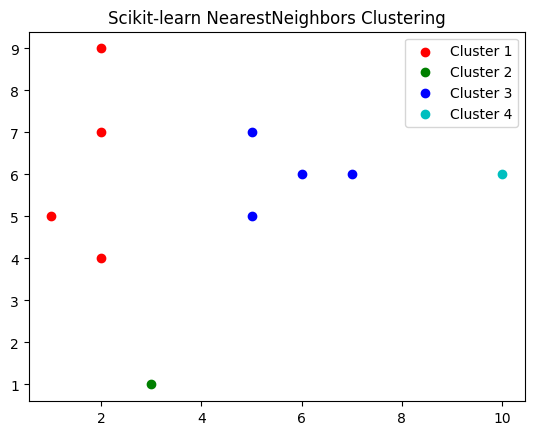

In [ ]:
from clasterization import nn_clustering
from sklearn.neighbors import NearestNeighbors

nn_threashold = 2.5
# Custom Nearest Neighbors Clustering
centers = nn_clustering(dataset, nn_threashold)

# Scikit-learn NearestNeighbors
knn_sklearn = NearestNeighbors(radius=nn_threashold)
knn_sklearn.fit(dataset)
neighbors = knn_sklearn.radius_neighbors(dataset, return_distance=False)
labels = np.full(len(dataset), -1)

cluster_id = mark_labels_with_clusters(neighbors, labels)

# Convert label array to array of clusters (list of lists of indices)
nn_sklearn_clusters = []
for cid in range(cluster_id):
    nn_sklearn_clusters.append(np.where(labels == cid)[0].tolist())

def plot_clusters(dataset, clusters, title="Clusters"):
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

    for idx, cluster in enumerate(clusters):
        points = dataset[cluster]
        plt.scatter(points[:, 0], points[:, 1], color=colors[idx % len(colors)], label=f'Cluster {idx+1}')

    plt.title(title)
    plt.legend()
    plt.show()

plot_clusters(dataset, centers, title="Custom Nearest Neighbors Clustering")
plot_clusters(dataset, nn_sklearn_clusters, title="Scikit-learn NearestNeighbors Clustering")

## DBSCAN

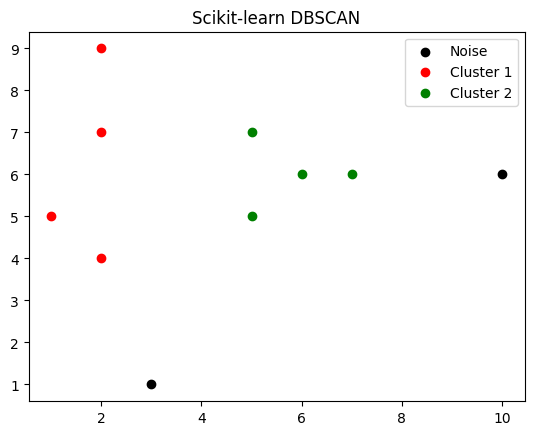

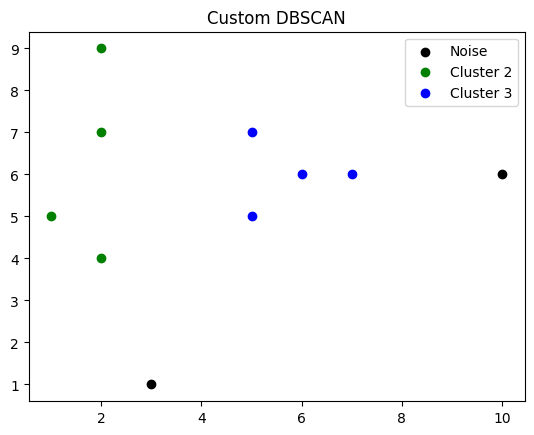

In [32]:
from clasterization import dbscan
from sklearn.cluster import DBSCAN

eps = 2.5
min_samples = 2
dbscan_sklearn = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_sklearn_labels = dbscan_sklearn.fit_predict(dataset)

dbscan_custom_labels = dbscan(dataset, eps=eps, min_samples=min_samples)

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

def plot_dbscan_clusters(dataset, labels, title):
    unique_labels = np.unique(labels)
    for idx, label in enumerate(unique_labels):
        if label == -1:
            color = 'k'  # Noise points
        else:
            color = colors[label % len(colors)]
        points = dataset[labels == label]
        plt.scatter(points[:, 0], points[:, 1], color=color, label=f'Cluster {label+1}' if label != -1 else 'Noise')

    plt.title(title)
    plt.legend()
    plt.show()

plot_dbscan_clusters(dataset, dbscan_sklearn_labels, "Scikit-learn DBSCAN")
plot_dbscan_clusters(dataset, dbscan_custom_labels, "Custom DBSCAN")

## Ієрархічний метод

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage
from clasterization import hierarchical_clustering

def plot_clustering_comparison(data, method):
    custom_res = hierarchical_clustering(data, linkage=method)

    scipy_res = linkage(data, method=method)

    custom_labels = [f"({x},{y})" for x, y in data]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    dendrogram(custom_res, labels=custom_labels, ax=axes[0], orientation='top')
    axes[0].set_title(f"Custom\n({method}-linkage)")
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].scatter(data[:, 0], data[:, 1], color='steelblue')
    for i, (x, y) in enumerate(data):
        axes[1].text(x + 0.1, y + 0.1, f"{i}\n({x},{y})", fontsize=9, ha='left', va='bottom')
    axes[1].set_title("Data Points")

    dendrogram(scipy_res, labels=custom_labels, ax=axes[2], orientation='top')
    axes[2].set_title(f"SciPy\n({method}-linkage)")
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

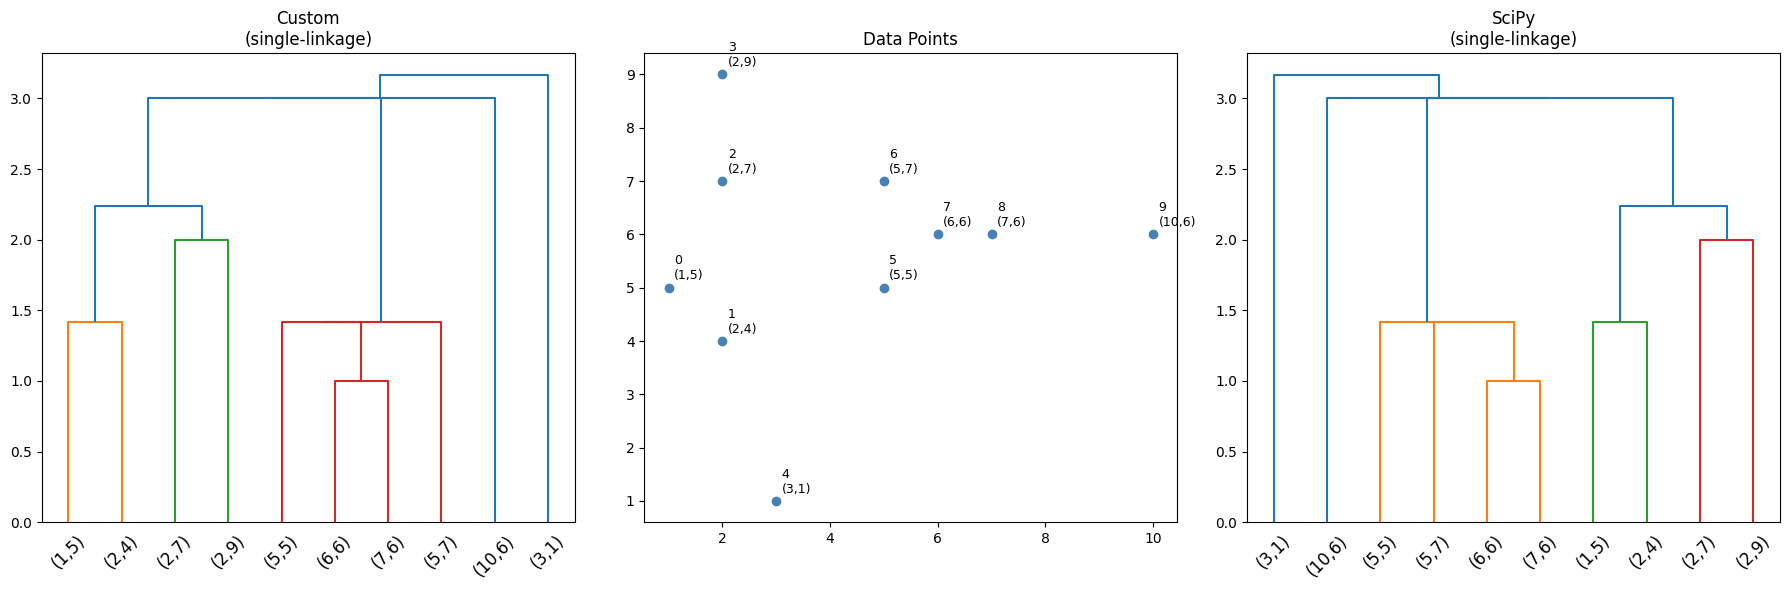

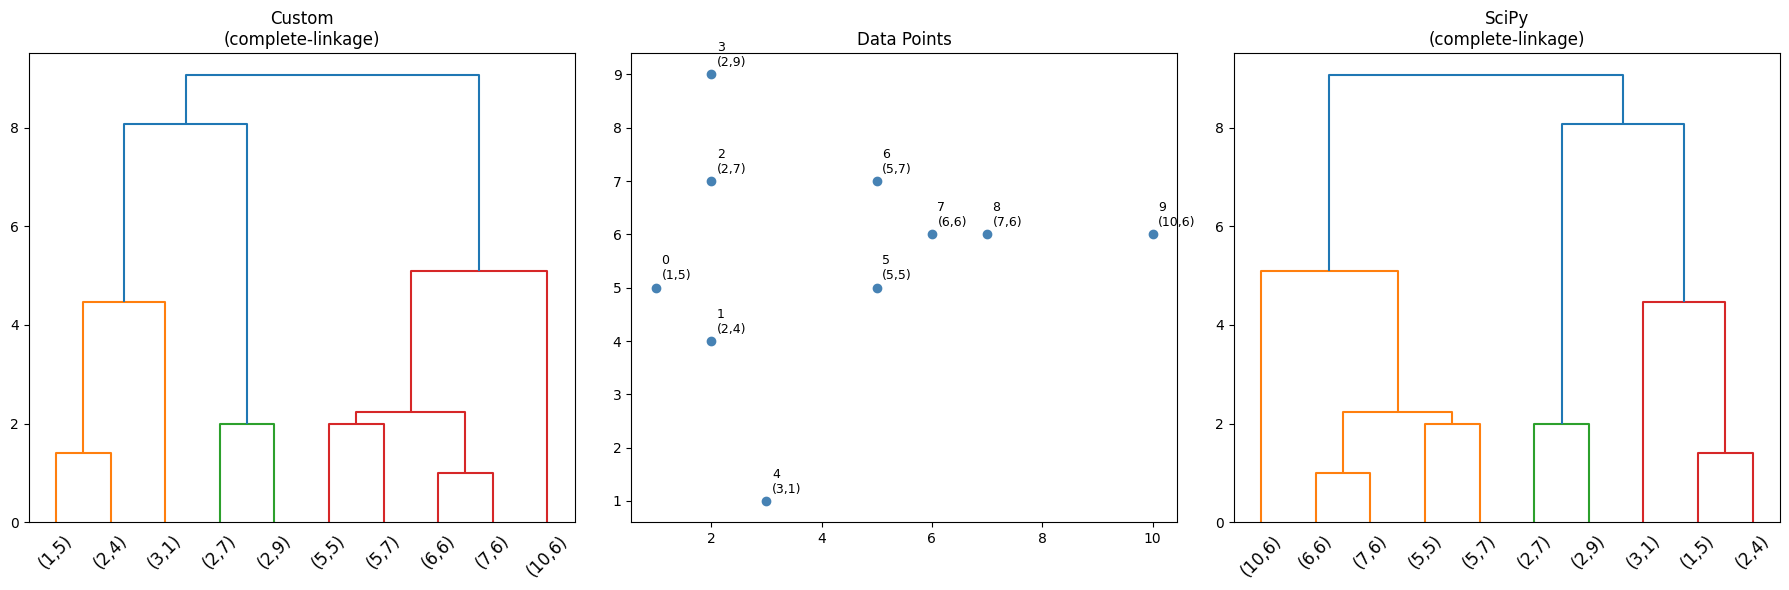

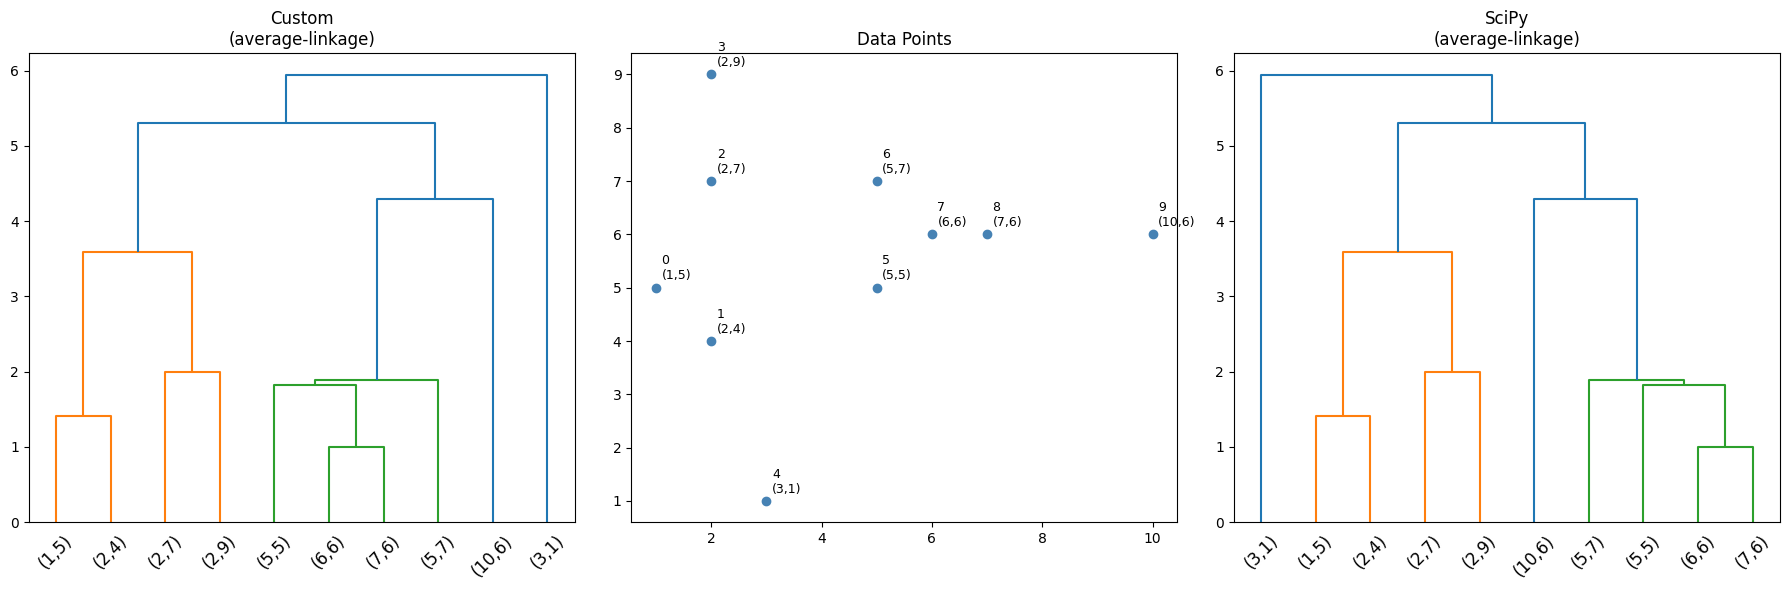

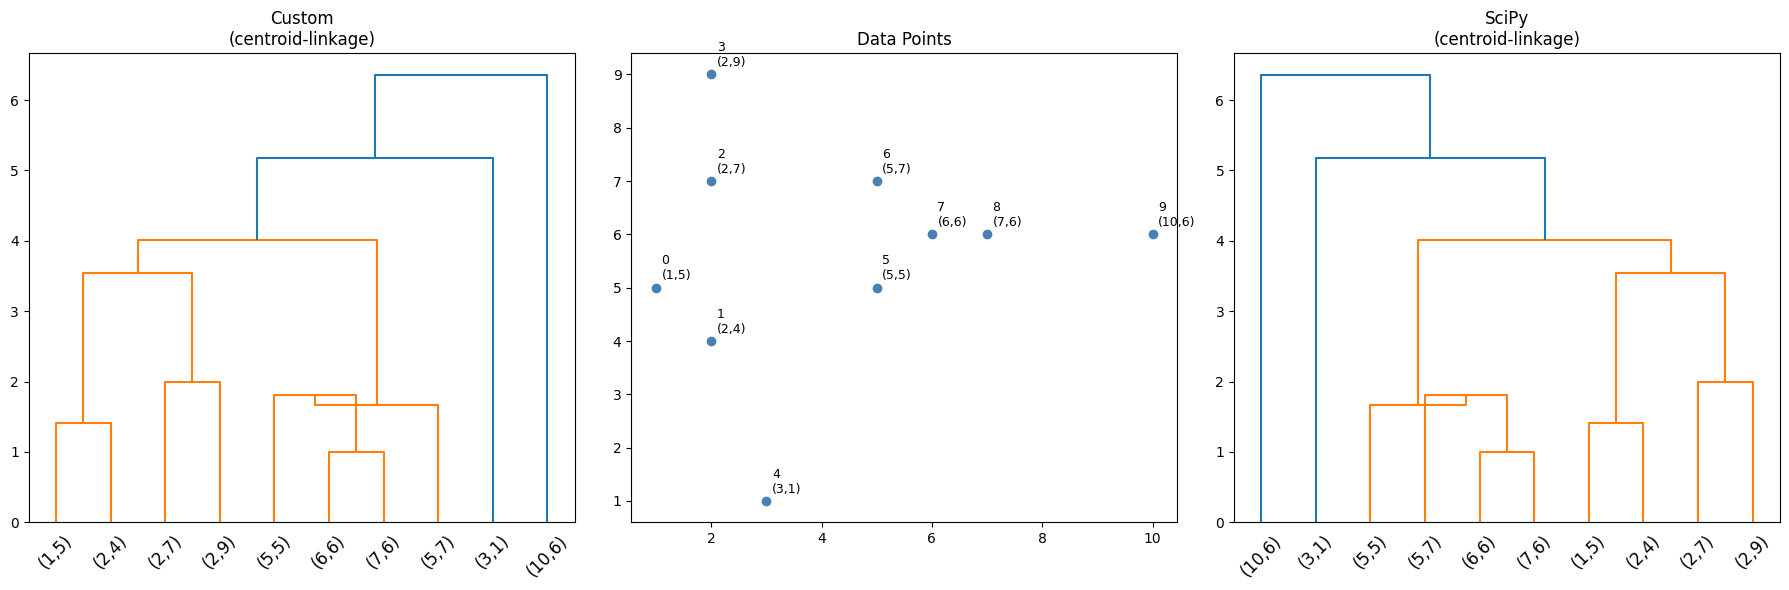

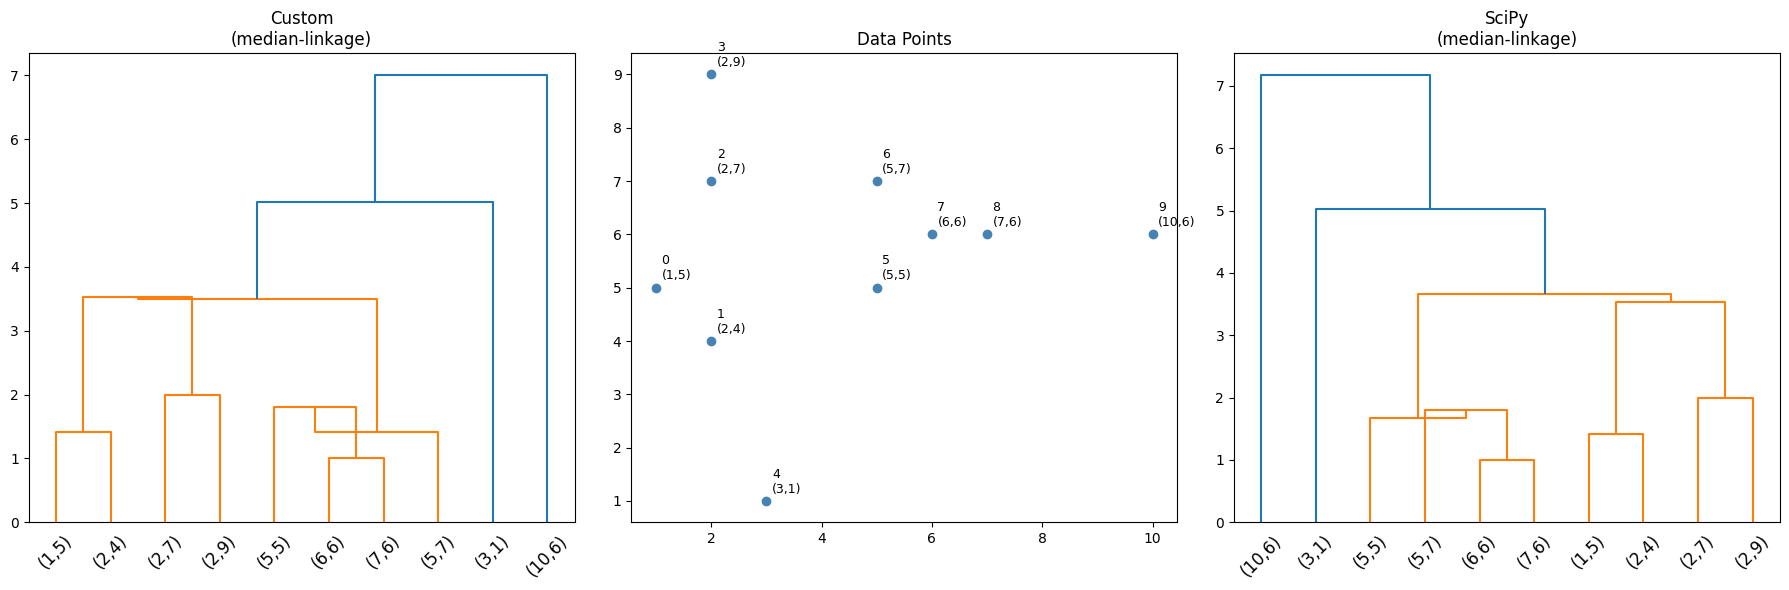

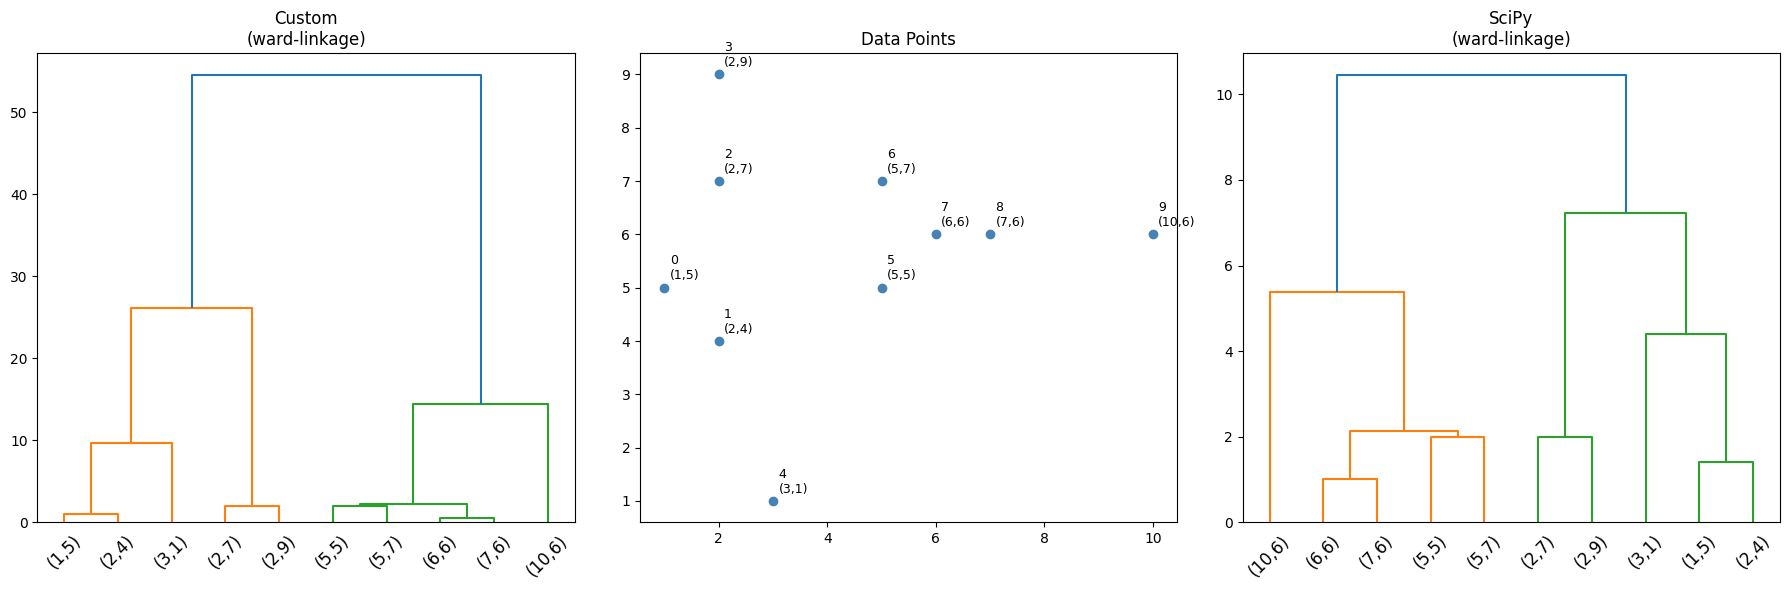

In [34]:
for method in ['single', 'complete', 'average', 'centroid', 'median', 'ward']:
    plot_clustering_comparison(dataset, method)

Результати ієрархічної кластеризації з використанням різних методів (linkage) показують правильність власноручної імплементації, оскільки маркування елементів кластерів збігається. Є деякі відмінності в значеннях linkage, що можливі через різницю в точності обчислень або реалізації методів обчислення відстані між точками.  

## Висновок

У висновку можна сказати, що власноручну реалізацію алгоритмів кластеризації виконано успішно, результати або повністю сходяться із бібліотечними рішеннями, або максимально наближені до них. Відмінності можливі через додаткові оптимізації та покращення, що не входять в базовий опис алгоритмів.